In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('Fraud.csv')
display(df.head())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.shape

(6362620, 11)

In [4]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: type
['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']

Column: nameOrig
['C1231006815' 'C1666544295' 'C1305486145' ... 'C1162922333' 'C1685995037'
 'C1280323807']

Column: nameDest
['M1979787155' 'M2044282225' 'C553264065' ... 'C1850423904' 'C1881841831'
 'C2080388513']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
print(f"fraud ratio :" , f"{df['isFraud'].mean() * 100:.2f}%")
print(df['isFraud'].value_counts())

fraud ratio : 0.13%
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [7]:
display(df.describe())

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


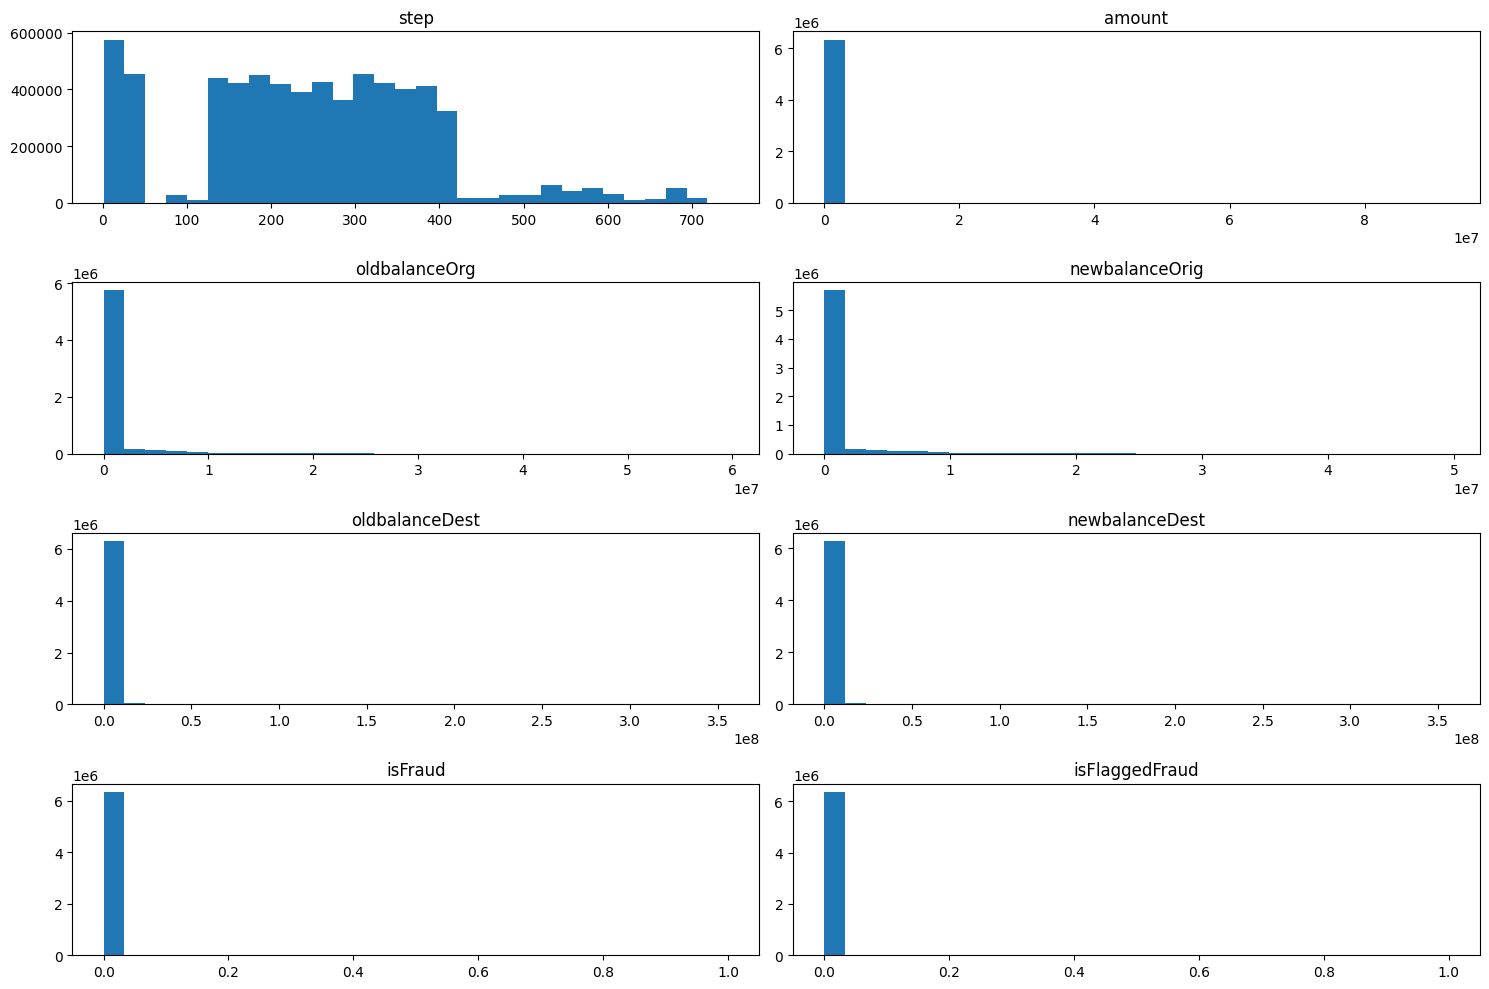

In [3]:
import matplotlib.pyplot as plt 

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
fig, axes = plt.subplots(4, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='none')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

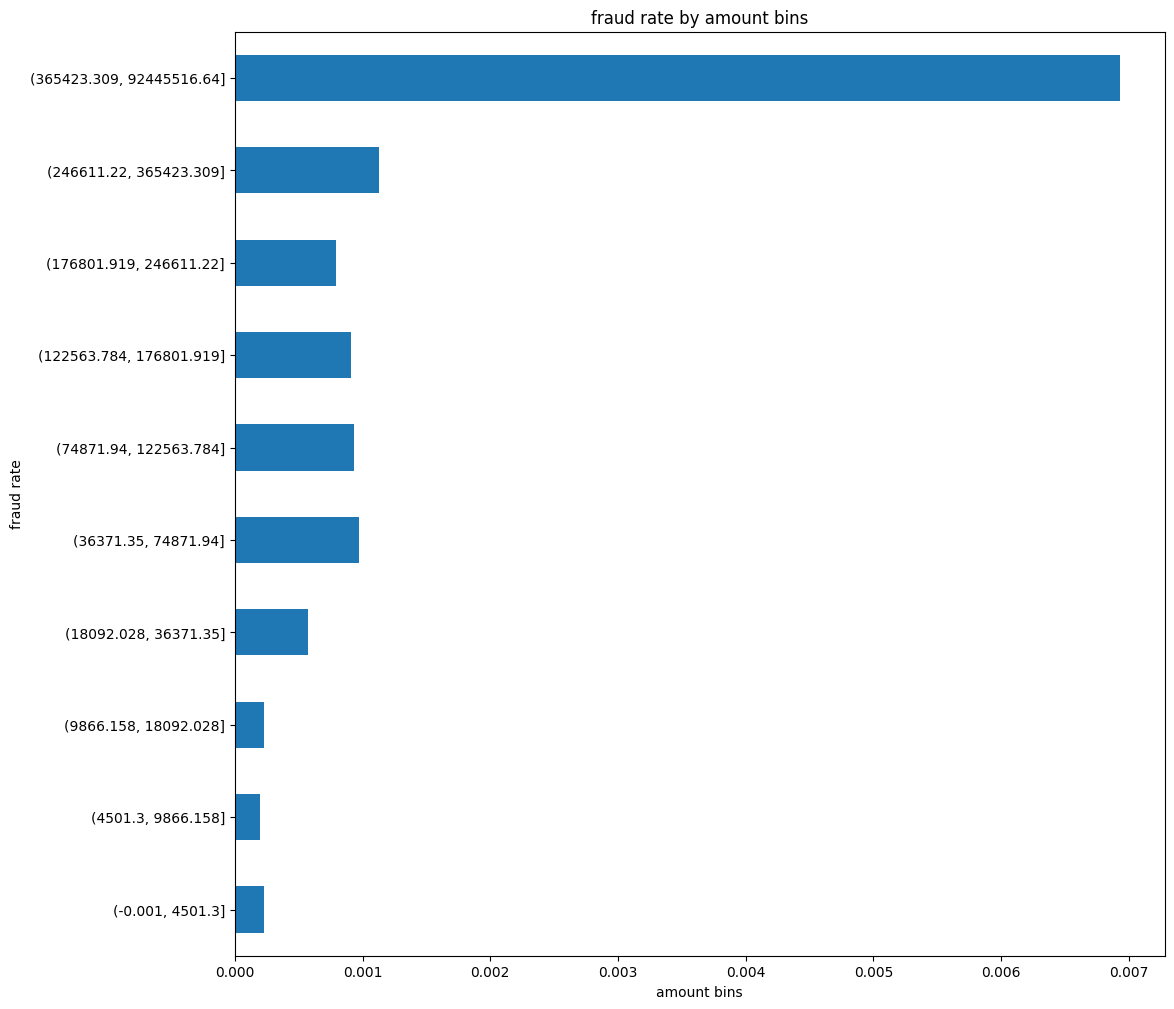

In [4]:
df['amount_bins'] = pd.qcut(df['amount'] , q = 10 , duplicates='drop')
fraude_rate = df.groupby('amount_bins')['isFraud'].mean()
plt.figure(figsize=(12,12))
fraude_rate.plot(kind='barh')
plt.title('fraud rate by amount bins')
plt.xlabel('amount bins')
plt.ylabel('fraud rate')
plt.show()

In [ ]:
merchant_tx = df[df['nameDest'].str.startswith('M')]
merchant_tx[['oldbalanceDest' , 'newbalanceDest']].describe()


,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [29]:
c_tx = df[df['nameDest'].str.startswith('C')]
c_tx[['oldbalanceDest' , 'newbalanceDest']].describe()

,oldbalanceDest,newbalanceDest
count,4.211125e+06,4.211125e+06
mean,1.663058e+06,1.850856e+06
std,4.064780e+06,4.386080e+06
min,0.000000e+00,0.000000e+00
25%,1.396590e+05,2.217176e+05
50%,5.512472e+05,6.837248e+05
75%,1.692951e+06,1.910979e+06
max,3.560159e+08,3.561793e+08


In [6]:
df['amount'].skew()

np.float64(30.99394948249041)

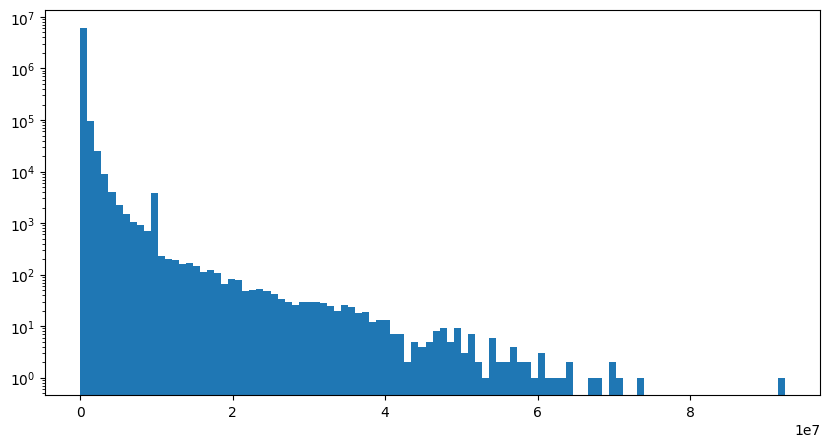

In [7]:
df['amount'].describe()

plt.figure(figsize=(10,5))
plt.hist(df['amount'],bins=100)
plt.yscale('log')
plt.show()

In [ ]:
# log transformation to reduce skewness
import numpy as np
df['log_amount'] = np.log1p(df['amount'])

# flag transaction above 99 percentile
p99 = df['amount'].quantile(0.99)
df['is_high_amount'] = (df['amount']> p99).astype(int)
df['is_high_amount'].value_counts()

is_high_amount
0    6298993
1      63627
Name: count, dtype: int64

👆is_high_amount flag the top 1 % of transaction amount , capturing extream value behavior that is strongly associated with fraude while retaining all original data

In [20]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_bins
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,"(4501.3, 9866.158]"
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,"(-0.001, 4501.3]"
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,"(-0.001, 4501.3]"
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,"(-0.001, 4501.3]"
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,"(9866.158, 18092.028]"
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,"(246611.22, 365423.309]"
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,"(365423.309, 92445516.64]"
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,"(365423.309, 92445516.64]"
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,"(365423.309, 92445516.64]"


quick overview

In [25]:
total_data = len(df)
fraud_cnt = df['isFraud'].sum() # is Fraud = 1
fraud_rate = fraud_cnt / total_data
flagged_pct = (df['isFlaggedFraud'].sum() / total_data) * 100
print(f"total transaction : {total_data}")
print(f"fraud transaction : {fraud_cnt}")
print(f"overall fraud ratio : {fraud_rate:.4%}")
print(f"non fraud transaction : {total_data - fraud_cnt}")
print(f"flagged transaction (isFlagged = 1): {flagged_pct : .2%}")

total transaction : 6362620
fraud transaction : 8213
overall fraud ratio : 0.1291%
non fraud transaction : 6354407
flagged transaction (isFlagged = 1):  0.03%


fraud rate by transaction type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


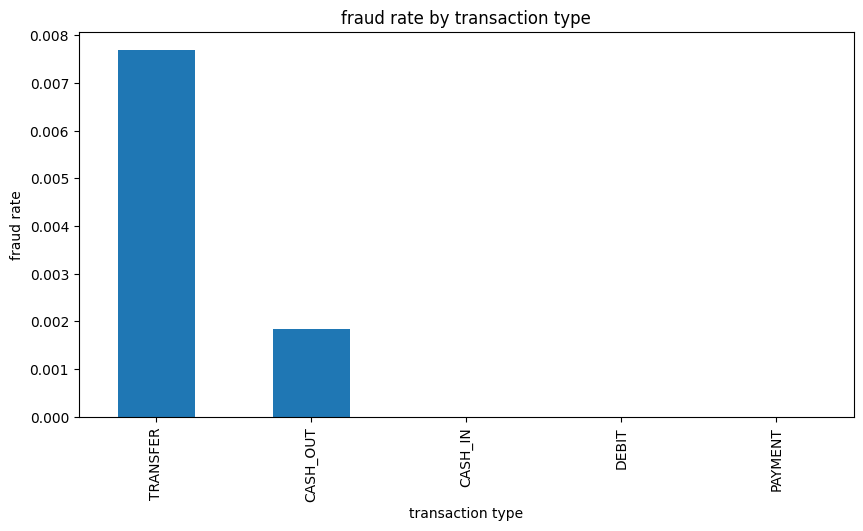

In [28]:
fraud_by_transaction = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
print(fraud_by_transaction)

plt.figure(figsize=(10,5))
fraud_by_transaction.plot(kind='bar')
plt.title('fraud rate by transaction type')
plt.xlabel("transaction type")
plt.ylabel('fraud rate')
plt.show()

time based overview

In [32]:
df['hour'] = df['step'] % 24

hourly_stat = df.groupby('hour').agg(
    total_transaction=('isFraud' , 'count'),
    fraud_transaction = ('isFraud' , 'sum'),
    fraud_rate_ = ('isFraud' , 'mean')
).reset_index()

display(hourly_stat.head(10))

,hour,total_transaction,fraud_transaction,fraud_rate_
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790
5,5,1641,366,0.223035
6,6,3420,358,0.104678
7,7,8988,328,0.036493
8,8,26915,368,0.013673
9,9,283518,341,0.001203


fraud rate by hour

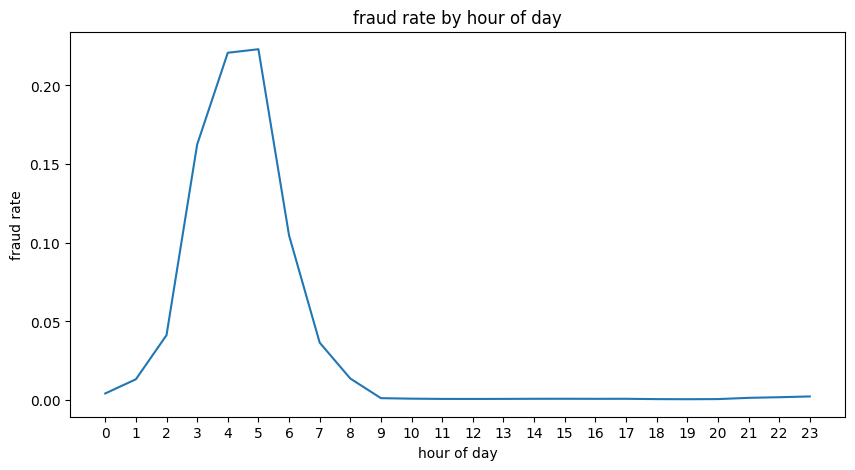

In [42]:
fraud_by_hour = df.groupby('hour')['isFraud'].mean().sort_values(ascending=True)
# print(fraud_by_hour)

plt.figure(figsize=(10,5))
plt.plot(hourly_stat['hour'] , hourly_stat['fraud_rate_'])
plt.title('fraud rate by hour of day')
plt.xlabel("hour of day")
plt.ylabel('fraud rate')
plt.xticks(hourly_stat['hour'])
plt.show()

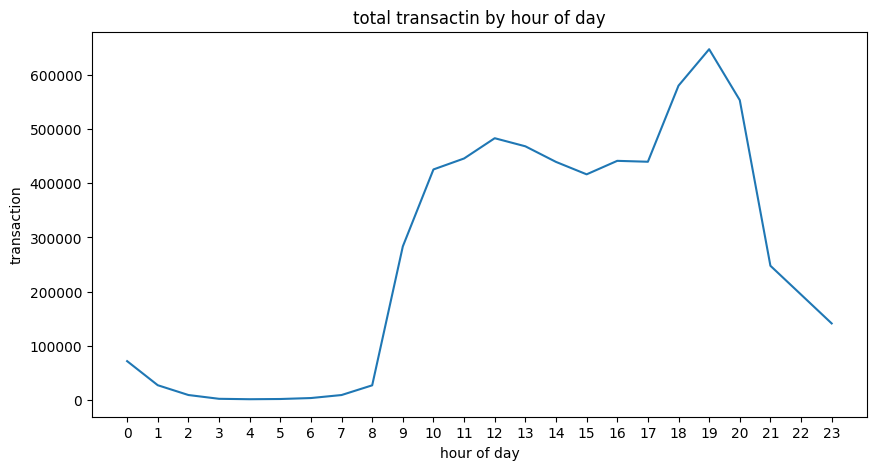

In [45]:
# total transaction by hour
plt.figure(figsize=(10,5))
plt.plot(hourly_stat['hour'] , hourly_stat['total_transaction'])
plt.title('total transactin by hour of day')
plt.xlabel("hour of day")
plt.ylabel('transaction')
plt.xticks(hourly_stat['hour'])
plt.show()

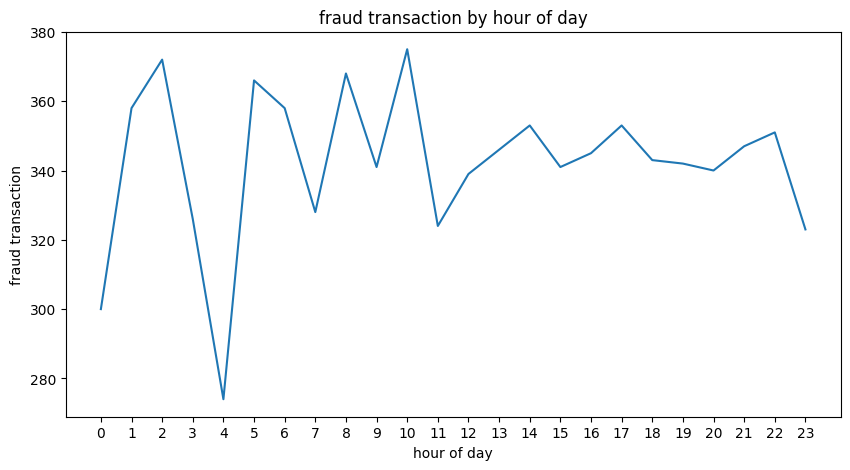

In [46]:
# fraud transaction by hour
plt.figure(figsize=(10,5))
plt.plot(hourly_stat['hour'] , hourly_stat['fraud_transaction'])
plt.title('fraud transaction by hour of day')
plt.xlabel("hour of day")
plt.ylabel('fraud transaction')
plt.xticks(hourly_stat['hour'])
plt.show()

dat vs night fraud comparision

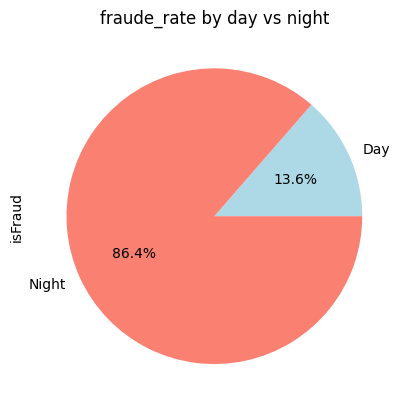

In [51]:
df['is_night']  = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)
night_fraud = df.groupby('is_night')['isFraud'].mean()
night_fraud.plot(kind='pie', autopct='%1.1f%%', labels=['Day', 'Night'], colors=['lightblue', 'salmon'])
plt.title("fraude_rate by day vs night")
plt.show()

<Axes: >

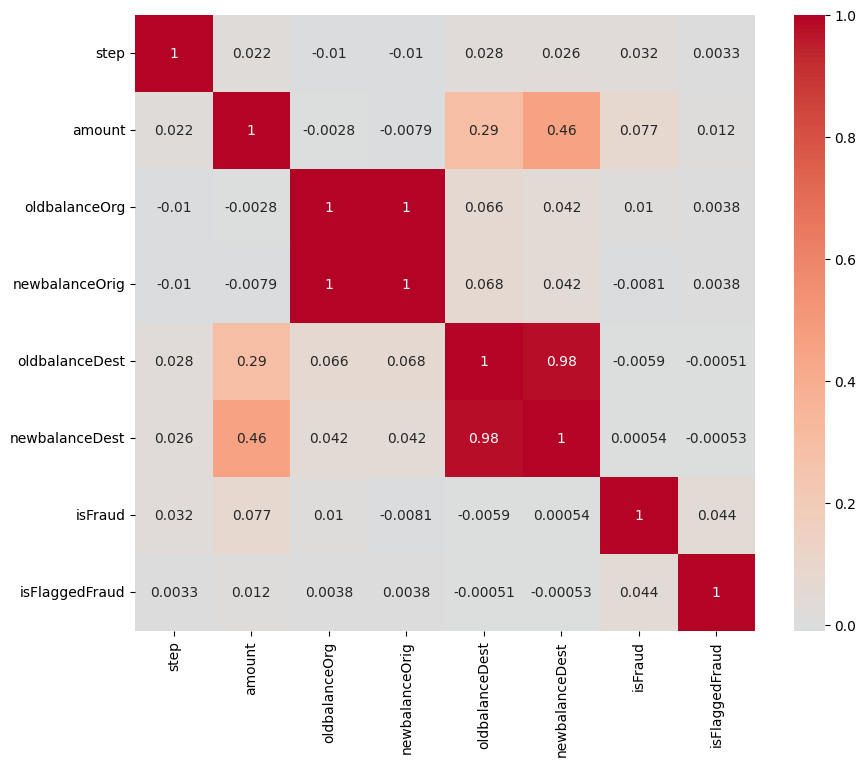

In [57]:
# corelation betwen numeric feature
import seaborn as sns
df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True , 
         cmap='coolwarm' , center=0)

# Feature Engneering

In [ ]:
# balance diff
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['oldbalanceDest'] - df['newbalanceDest']

# feature reduction (for linear model here logistic regression)
df.drop(columns= ['oldbalanceOrg' , 'newbalanceOrig','oldbalanceDest','newbalanceDest'] , inplace = True)

In [68]:
df.drop(columns=['amount_bins' , 'nameOrig','nameDest'] , inplace = True)

In [72]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])
df.drop(columns=['type'] , inplace = True)

In [ ]:
df.to_csv('train_data.csv' , index=False)        